In [1]:
import geopandas as gp
import matplotlib as plt
import pandas as pd
import glob
import os

In [2]:
import zipfile
import os

zip_path = "nepal_shape/npl_admin_boundaries.shp.zip"
extract_path = "nepal_shape/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
import geopandas as gpd

nepal_map = gpd.read_file("nepal_shape/npl_admin2.shp")
nepal_map.head(10)

,adm2_name,adm2_name1,adm2_name2,adm2_name3,adm2_pcode,adm1_name,adm1_name1,adm1_name2,adm1_name3,adm1_pcode,...,valid_to,area_sqkm,cod_versio,lang,lang1,lang2,lang3,center_lat,center_lon,geometry
0,Taplejung,None,None,None,NP0101,Koshi,None,None,None,NP01,...,NaT,3631.813309,V_02,en,None,None,None,27.610463,87.821542,"POLYGON ((87.83403 27.95158, 87.83465 27.95139..."
1,Panchthar,None,None,None,NP0102,Koshi,None,None,None,NP01,...,NaT,1247.722512,V_02,en,None,None,None,27.148871,87.855072,"POLYGON ((88.07442 27.43312, 88.07464 27.43312..."
2,Ilam,None,None,None,NP0103,Koshi,None,None,None,NP01,...,NaT,1685.282883,V_02,en,None,None,None,26.885396,87.920240,"POLYGON ((87.95472 27.10455, 87.95545 27.10444..."
3,Jhapa,None,None,None,NP0104,Koshi,None,None,None,NP01,...,NaT,1603.810951,V_02,en,None,None,None,26.583568,87.885501,"POLYGON ((88.15222 26.80584, 88.1528 26.80534,..."
4,Morang,None,None,None,NP0105,Koshi,None,None,None,NP01,...,NaT,1822.340361,V_02,en,None,None,None,26.610614,87.473116,"POLYGON ((87.50698 26.8704, 87.50738 26.86958,..."
5,Sunsari,None,None,None,NP0106,Koshi,None,None,None,NP01,...,NaT,1191.886527,V_02,en,None,None,None,26.640886,87.140876,"POLYGON ((87.23805 26.8757, 87.23907 26.87549,..."
6,Dhankuta,None,None,None,NP0107,Koshi,None,None,None,NP01,...,NaT,898.710130,V_02,en,None,None,None,27.018036,87.313067,"POLYGON ((87.3575 27.19013, 87.35853 27.18925,..."
7,Terhathum,None,None,None,NP0108,Koshi,None,None,None,NP01,...,NaT,670.492104,V_02,en,None,None,None,27.132469,87.524284,"POLYGON ((87.5355 27.29116, 87.53626 27.29104,..."
8,Sankhuwasabha,None,None,None,NP0109,Koshi,None,None,None,NP01,...,NaT,3469.613882,V_02,en,None,None,None,27.547676,87.226501,"POLYGON ((87.01829 27.95398, 87.01926 27.9533,..."
9,Bhojpur,None,None,None,NP0110,Koshi,None,None,None,NP01,...,NaT,1523.588644,V_02,en,None,None,None,27.175066,87.093789,"POLYGON ((87.10965 27.46217, 87.10971 27.46186..."


<Axes: >

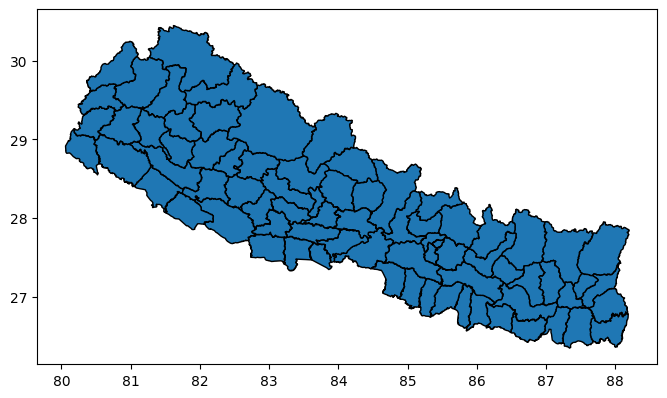

In [4]:
nepal_map.plot(figsize=(8,8), edgecolor='black')

In [5]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

# Get all shapefiles
shp_files = list(Path("data").glob("*/*.shp"))

# ❗ Filter out invalid files (starting with ._)
shp_files = [f for f in shp_files if not f.name.startswith("._")]

fire_data_list = []

for file in shp_files:
    try:
        gdf = gpd.read_file(file)
        
        year = file.parent.name
        gdf['year'] = int(year)
        
        fire_data_list.append(gdf)
    
    except Exception as e:
        print(f"Skipping file: {file} → {e}")

fire_data = gpd.GeoDataFrame(pd.concat(fire_data_list, ignore_index=True))

fire_data.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,year
0,26.90225,85.80494,328.11,0.40,0.37,2020-01-02,0729,N20,VIIRS,n,2,290.10,2.20,D,0,POINT (85.80494 26.90225),2020
1,27.47337,84.33176,328.18,0.38,0.36,2020-01-02,0729,N20,VIIRS,n,2,291.14,2.03,D,0,POINT (84.33176 27.47337),2020
2,27.47309,82.85561,327.18,0.40,0.37,2020-01-02,0729,N20,VIIRS,n,2,293.35,2.15,D,0,POINT (82.85561 27.47309),2020
3,28.77123,80.20963,337.18,0.49,0.49,2020-01-05,0814,N20,VIIRS,n,2,290.54,6.05,D,0,POINT (80.20963 28.77123),2020
4,27.62135,83.08981,295.71,0.42,0.38,2020-01-06,2020,N20,VIIRS,n,2,277.86,0.42,N,0,POINT (83.08981 27.62135),2020


In [6]:
if fire_data.crs != nepal_map.crs:
    fire_data = fire_data.to_crs(nepal_map.crs)

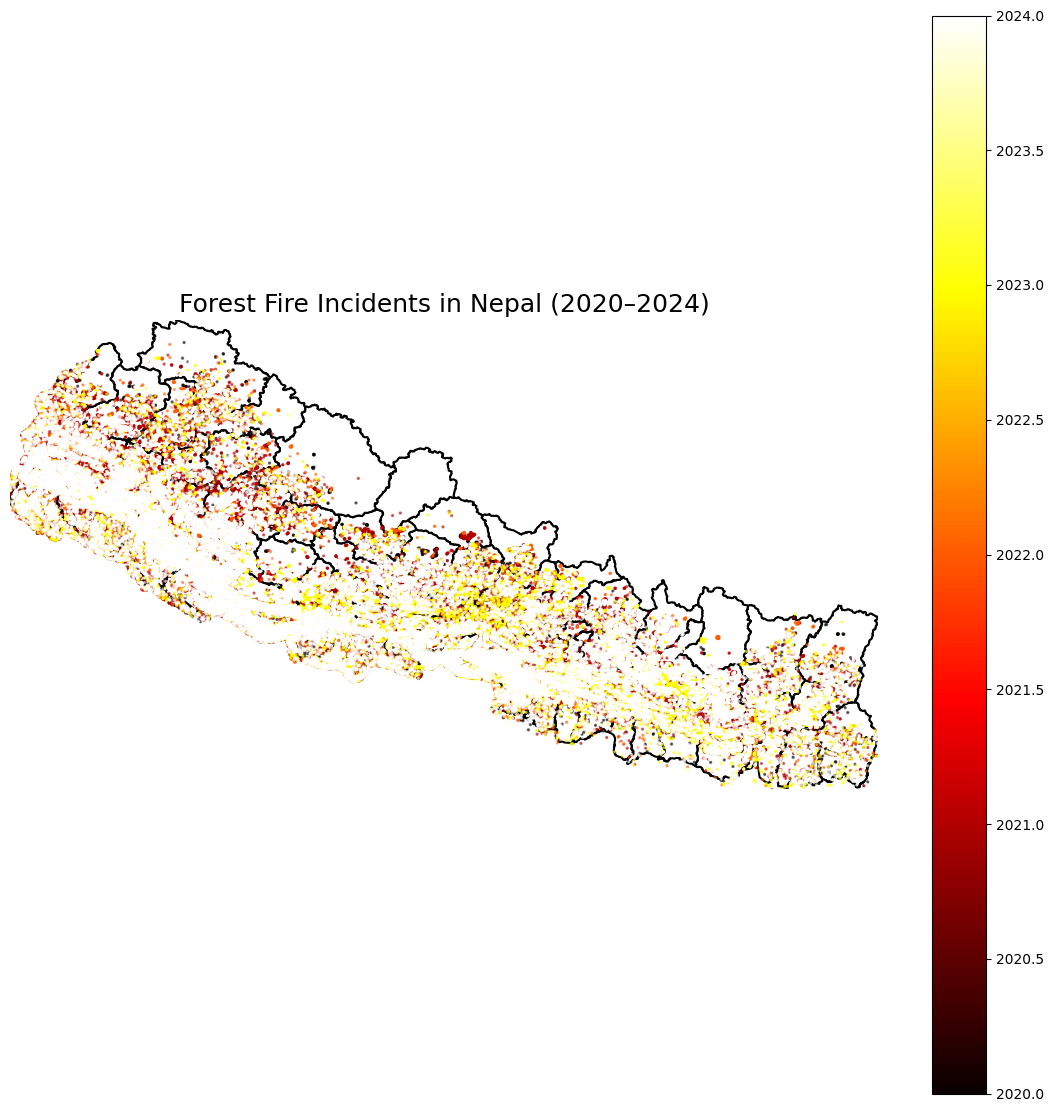

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 14))

# Nepal boundary
nepal_map.plot(
    ax=ax,
    color='white',
    edgecolor='black',
    linewidth=1.5
)

# Fire points
fire_data.plot(
    ax=ax,
    column='year',
    cmap='hot',
    markersize=2,     # slightly bigger for visibility
    alpha=0.5,
    legend=True
)

# Zoom exactly to Nepal boundary
ax.set_xlim(nepal_map.total_bounds[[0, 2]])
ax.set_ylim(nepal_map.total_bounds[[1, 3]])

# Clean map
ax.set_title("Forest Fire Incidents in Nepal (2020–2024)", fontsize=18)
ax.set_axis_off()

plt.show()

In [8]:
print(nepal_map.columns)

Index(['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode',
       'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',
       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',
       'valid_on', 'valid_to', 'area_sqkm', 'cod_versio', 'lang', 'lang1',
       'lang2', 'lang3', 'center_lat', 'center_lon', 'geometry'],
      dtype='str')


In [9]:
fire_with_district = gpd.sjoin(
    fire_data,
    nepal_map,
    how="inner",
    predicate="within"
)

In [10]:
district_yearly = fire_with_district.groupby(
    ['adm2_name', 'year']
).size().reset_index(name='fire_count')

In [11]:
print(district_yearly.head())

  adm2_name  year  fire_count
0    Achham  2020          68
1    Achham  2021        1578
2    Achham  2022         679
3    Achham  2023         687
4    Achham  2024        1138


In [127]:
district_yearly_sorted = district_yearly.sort_values(
    by='fire_count',
    ascending=False
)

print(district_yearly_sorted.head(10))

     adm2_name  year  fire_count
354    Surkhet  2021        3646
69        Dang  2021        3512
72        Dang  2024        3288
144    Kailali  2021        3192
357    Surkhet  2024        3086
147    Kailali  2024        2769
199  Makwanpur  2021        2733
41     Bardiya  2021        2497
54    Chitawan  2021        2437
104       Doti  2021        2427


In [12]:
pivot_table = district_yearly.pivot(
    index='adm2_name',
    columns='year',
    values='fire_count'
).fillna(0)

print(pivot_table)

year           2020    2021   2022    2023    2024
adm2_name                                         
Achham         68.0  1578.0  679.0   687.0  1138.0
Arghakhanchi   13.0  1116.0  242.0   760.0  1024.0
Baglung        22.0   229.0   56.0    90.0   409.0
Baitadi        14.0   805.0  425.0   151.0   624.0
Bajhang       181.0   625.0  151.0   175.0   364.0
...             ...     ...    ...     ...     ...
Syangja        77.0   556.0   13.0   361.0   513.0
Tanahu        206.0   731.0   38.0   512.0   325.0
Taplejung     134.0   123.0  186.0   124.0   344.0
Terhathum     118.0   199.0   95.0   217.0   316.0
Udayapur      414.0  1582.0  269.0  1103.0  1114.0

[77 rows x 5 columns]


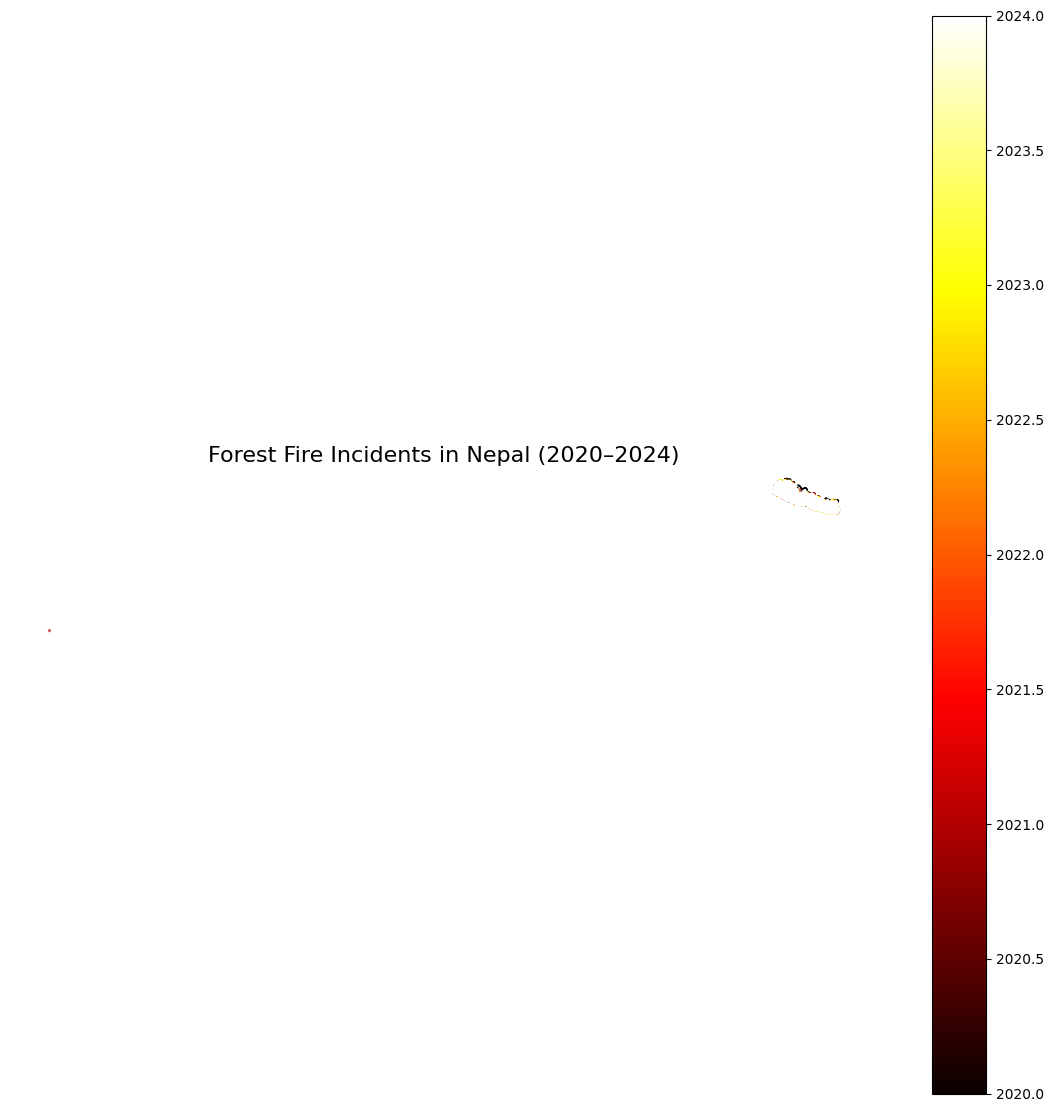

In [13]:
fig, ax = plt.subplots(figsize=(14, 14))  # bigger map

nepal_map.plot(
    ax=ax,
    color='white',
    edgecolor='black',
    linewidth=1
)

fire_data.plot(
    ax=ax,
    column='year',
    cmap='hot',
    markersize=2,
    alpha=0.5,
    legend=True
)

ax.set_title("Forest Fire Incidents in Nepal (2020–2024)", fontsize=16)
ax.set_axis_off()

plt.show()

In [14]:
top_districts = district_yearly.sort_values(
    ['year', 'fire_count'],
    ascending=[True, False]
).groupby('year').head(5)

print(top_districts)

     adm2_name  year  fire_count
53    Chitawan  2020         487
198  Makwanpur  2020         461
108     Gorkha  2020         430
378   Udayapur  2020         414
263      Parsa  2020         413
354    Surkhet  2021        3646
69        Dang  2021        3512
144    Kailali  2021        3192
199  Makwanpur  2021        2733
41     Bardiya  2021        2497
70        Dang  2022        1554
42     Bardiya  2022        1493
32       Banke  2022        1451
145    Kailali  2022        1087
355    Surkhet  2022        1059
56    Chitawan  2023        2014
71        Dang  2023        1820
201  Makwanpur  2023        1459
33       Banke  2023        1425
266      Parsa  2023        1421
72        Dang  2024        3288
357    Surkhet  2024        3086
147    Kailali  2024        2769
44     Bardiya  2024        2252
312     Salyan  2024        2251


In [16]:
yearly_total = fire_with_district.groupby('year').size().reset_index(name='total_fire_count')

print(yearly_total)

   year  total_fire_count
0  2020              8582
1  2021             61251
2  2022             17975
3  2023             34472
4  2024             55341


In [17]:
yearly_total = yearly_total.sort_values('year')
print(yearly_total)

   year  total_fire_count
0  2020              8582
1  2021             61251
2  2022             17975
3  2023             34472
4  2024             55341


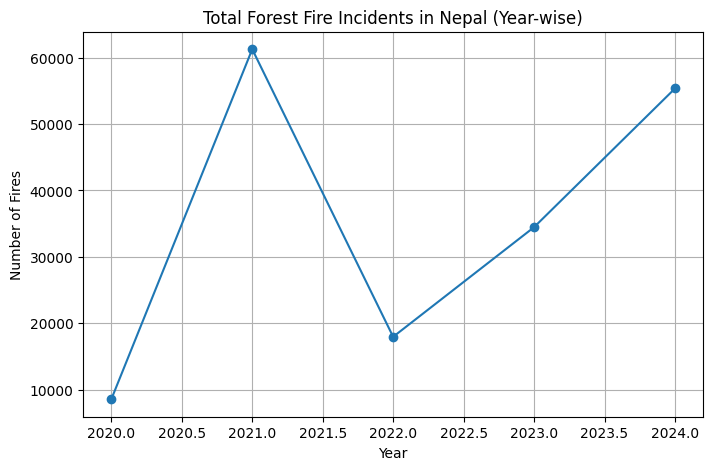

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    yearly_total['year'],
    yearly_total['total_fire_count'],
    marker='o'
)

plt.title("Total Forest Fire Incidents in Nepal (Year-wise)")
plt.xlabel("Year")
plt.ylabel("Number of Fires")
plt.grid(True)

plt.show()

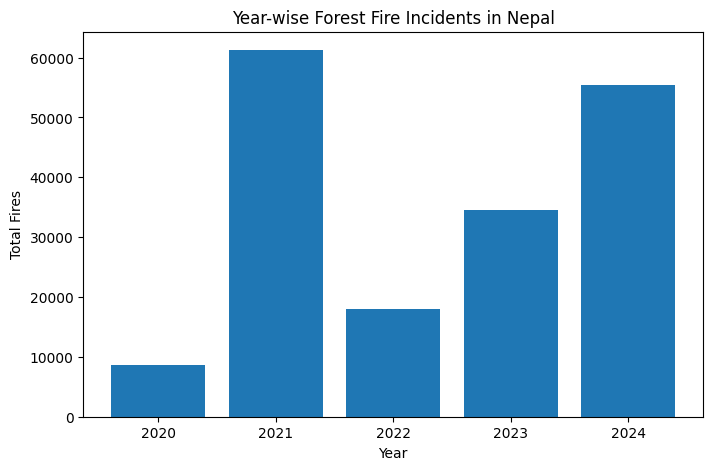

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_total['year'],
    yearly_total['total_fire_count']
)

plt.title("Year-wise Forest Fire Incidents in Nepal")
plt.xlabel("Year")
plt.ylabel("Total Fires")

plt.show()

In [20]:
max_year = yearly_total.loc[yearly_total['total_fire_count'].idxmax()]
print(max_year)

year                 2021
total_fire_count    61251
Name: 1, dtype: int64


In [21]:
import pandas as pd
import os

In [23]:
file_path = "data/Forest Cover.xlsx"
forest_cover_data = pd.read_excel(file_path)
forest_cover_data.head()

,S.NO,District,mean_slope_percent,Population Density,Road Density (Km/100 Km2),Rainfall 2020 mm,Forest Cover,Year
0,1,ACHHAM,55.410044,136.221429,7.51,1334.4,2.326786,2020
1,2,ARGHAKHANCHI,46.532218,148.437552,24.43,1775.4,0.568315,2020
2,3,BAGLUNG,62.384511,139.692265,12.55,2011.0,1.299327,2020
3,4,BAITADI,58.269744,159.418697,10.78,1501.8,0.809085,2020
4,5,BAJHANG,69.153910,55.255698,3.17,1366.0,5.914670,2020


In [24]:
features = ["DISTRICT", "YEAR", "FIRE_COUNT", "MEAN_SLOPE_PERCENT", "POPUTALTION_DENSITY", "ROAD_DENSITY", "RAINFALL_MM", "FOREST_COVER"]

In [25]:
district_yearly = district_yearly.rename(columns={'adm2_name': "District"})
district_yearly

,District,year,fire_count
0,Achham,2020,68
1,Achham,2021,1578
2,Achham,2022,679
3,Achham,2023,687
4,Achham,2024,1138
...,...,...,...
378,Udayapur,2020,414
379,Udayapur,2021,1582
380,Udayapur,2022,269
381,Udayapur,2023,1103


In [26]:
forest_cover_data = forest_cover_data.rename(columns={
    "DISTRICT": "District",
    "Year": "year",
    "mean_slope_percent": "mean_slope_percent",
    "Population Density": "population_density",
    "Road Density (Km/100 Km2)": "road_density",
    "Rainfall 2020 mm": "rainfall_mm",
    "Forest Cover": "forest_cover"
})

forest_cover_data

,S.NO,District,mean_slope_percent,Population Density,road_density,rainfall_mm,forest_cover,year
0,1,ACHHAM,55.410044,136.221429,7.51,1334.4,2.326786,2020
1,2,ARGHAKHANCHI,46.532218,148.437552,24.43,1775.4,0.568315,2020
2,3,BAGLUNG,62.384511,139.692265,12.55,2011.0,1.299327,2020
3,4,BAITADI,58.269744,159.418697,10.78,1501.8,0.809085,2020
4,5,BAJHANG,69.153910,55.255698,3.17,1366.0,5.914670,2020
...,...,...,...,...,...,...,...,...
380,381,SYANGJA,48.467455,217.374570,10.89,2736.3,0.526632,2024
381,382,TANAHU,44.988770,207.731565,10.01,2620.0,0.336999,2024
382,383,TAPLEJUNG,63.300035,33.074602,1.88,2446.1,1.039495,2024
383,384,TERHATHUM,44.355852,130.678940,17.80,1954.1,0.954345,2024


In [27]:
set1 = set(zip(district_yearly["District"], district_yearly["year"]))
set2 = set(zip(forest_cover_data["District"], forest_cover_data["year"]))

print("Only in fire:", set1 - set2)
print("Only in features:", set2 - set1)

Only in fire: {('Manang', 2022), ('Bajhang', 2021), ('Baglung', 2022), ('Dailekh', 2021), ('Syangja', 2022), ('Sankhuwasabha', 2021), ('Sarlahi', 2021), ('Bara', 2023), ('Mugu', 2020), ('Rupandehi', 2024), ('Kavrepalanchok', 2022), ('Dolpa', 2024), ('Sunsari', 2020), ('Kailali', 2020), ('Nawalparasi East', 2023), ('Khotang', 2024), ('Dhankuta', 2021), ('Lalitpur', 2023), ('Nawalparasi West', 2023), ('Myagdi', 2020), ('Solukhumbu', 2024), ('Ramechhap', 2023), ('Salyan', 2022), ('Dhading', 2020), ('Rukum East', 2023), ('Sunsari', 2024), ('Mahottari', 2021), ('Kailali', 2024), ('Jajarkot', 2020), ('Saptari', 2023), ('Dailekh', 2020), ('Baglung', 2021), ('Sankhuwasabha', 2020), ('Bara', 2022), ('Kaski', 2022), ('Rupandehi', 2023), ('Makwanpur', 2020), ('Dhading', 2024), ('Dolpa', 2023), ('Terhathum', 2020), ('Baitadi', 2024), ('Nawalparasi East', 2022), ('Khotang', 2023), ('Jajarkot', 2024), ('Dhankuta', 2020), ('Lalitpur', 2022), ('Doti', 2021), ('Nawalparasi West', 2022), ('Kalikot', 202

In [28]:
def clean_text(df, col):
    df[col] = df[col].str.upper().str.strip()
    return df

district_yearly = clean_text(district_yearly, "District")
forest_cover_data = clean_text(forest_cover_data, "District")

In [29]:
name_map = {
    "RUKUM_W": "RUKUM WEST",
    "RUKUM_E": "RUKUM EAST",
    "NAWALPARASI_W": "NAWALPARASI WEST",
    "NAWALPARASI_E": "NAWALPARASI EAST",
    "KATHMANDU": "KATHMANDU",
    "CHITAWAN": "CHITWAN",
    "MAKAWANPUR": "MAKWANPUR",
    "SINDHUPALCHOK": "SINDHUPALCHOWK"
}

In [35]:
forest_cover_data["District"] = forest_cover_data["District"].replace(name_map)
district_yearly["District"] = district_yearly["District"].replace(name_map)

In [36]:
set1 = set(zip(district_yearly["District"], district_yearly["year"]))
set2 = set(zip(forest_cover_data["District"], forest_cover_data["year"]))

print("Only in fire:", set1 - set2)
print("Only in features:", set2 - set1)

Only in fire: set()
Only in features: {('BHAKTAPUR', 2020), ('BHAKTAPUR', 2023)}


In [37]:
district_map = {
    "DHANUSA": "DHANUSHA",
    "KAVREPALANCHOK": "KABHREPALANCHOK"
}

In [38]:
district_yearly["District"] = district_yearly["District"].replace(district_map)
forest_cover_data["District"] = forest_cover_data["District"].replace(district_map)

In [39]:
set1 = set(zip(district_yearly["District"], district_yearly["year"]))
set2 = set(zip(forest_cover_data["District"], forest_cover_data["year"]))

print("Only in fire:", set1 - set2)
print("Only in features:", set2 - set1)

Only in fire: set()
Only in features: {('BHAKTAPUR', 2020), ('BHAKTAPUR', 2023)}


In [40]:
df = forest_cover_data.merge(
    district_yearly,
    on=["District", "year"],
    how="left"
)

In [41]:
df["fire_count"] = df["fire_count"].fillna(0)

In [42]:
df

,S.NO,District,mean_slope_percent,Population Density,road_density,rainfall_mm,forest_cover,year,fire_count
0,1,ACHHAM,55.410044,136.221429,7.51,1334.4,2.326786,2020,68.0
1,2,ARGHAKHANCHI,46.532218,148.437552,24.43,1775.4,0.568315,2020,13.0
2,3,BAGLUNG,62.384511,139.692265,12.55,2011.0,1.299327,2020,22.0
3,4,BAITADI,58.269744,159.418697,10.78,1501.8,0.809085,2020,14.0
4,5,BAJHANG,69.153910,55.255698,3.17,1366.0,5.914670,2020,181.0
...,...,...,...,...,...,...,...,...,...
380,381,SYANGJA,48.467455,217.374570,10.89,2736.3,0.526632,2024,513.0
381,382,TANAHU,44.988770,207.731565,10.01,2620.0,0.336999,2024,325.0
382,383,TAPLEJUNG,63.300035,33.074602,1.88,2446.1,1.039495,2024,344.0
383,384,TERHATHUM,44.355852,130.678940,17.80,1954.1,0.954345,2024,316.0


In [43]:
print(nepal_map.columns)

Index(['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode',
       'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',
       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',
       'valid_on', 'valid_to', 'area_sqkm', 'cod_versio', 'lang', 'lang1',
       'lang2', 'lang3', 'center_lat', 'center_lon', 'geometry'],
      dtype='str')


In [44]:
df["District"] = df["District"].str.upper().str.strip()
nepal_map["adm2_name"] = nepal_map["adm2_name"].str.upper().str.strip()

In [45]:
map_df = nepal_map.merge(
    df,
    left_on="adm2_name",
    right_on="District",
    how="left"
)

In [46]:
print(map_df[["adm2_name", "District", "fire_count"]].head())

   adm2_name   District  fire_count
0  TAPLEJUNG  TAPLEJUNG       134.0
1  TAPLEJUNG  TAPLEJUNG       123.0
2  TAPLEJUNG  TAPLEJUNG       186.0
3  TAPLEJUNG  TAPLEJUNG       124.0
4  TAPLEJUNG  TAPLEJUNG       344.0


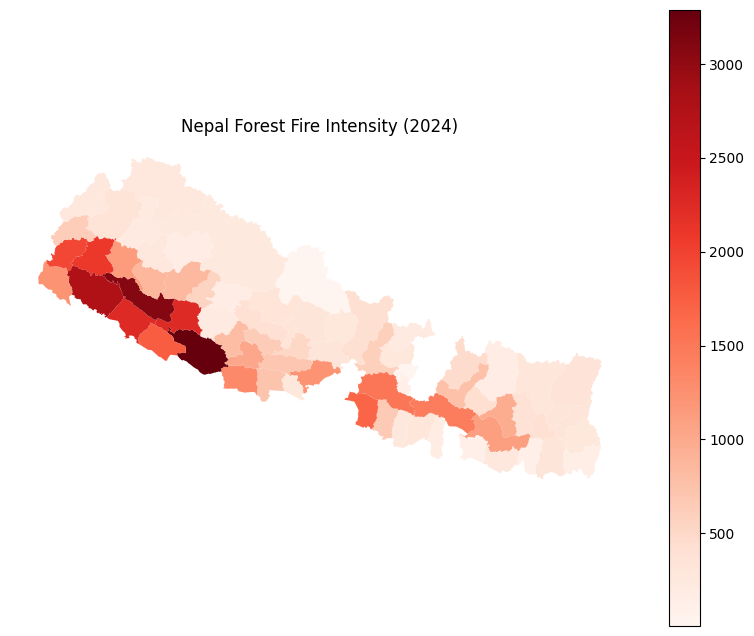

In [47]:
import matplotlib.pyplot as plt

year_map = map_df[map_df["year"] == 2024]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

year_map.plot(
    column="fire_count",
    cmap="Reds",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Nepal Forest Fire Intensity (2024)")
ax.axis("off")

plt.show()

In [48]:
map_df["risk_score"] = (
    map_df["fire_count"] / (map_df["fire_count"].max() + 1)
)

<Axes: >

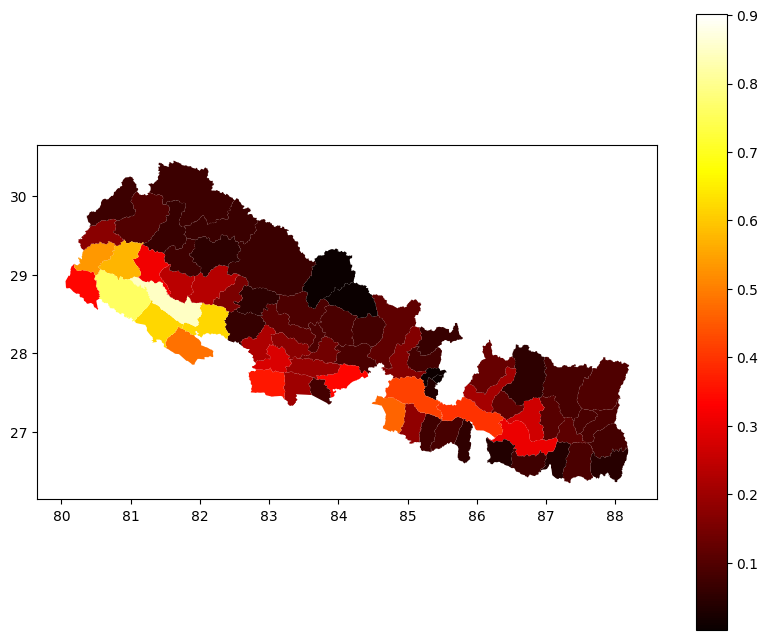

In [49]:
year_map = map_df[map_df["year"] == 2024]

year_map.plot(
    column="risk_score",
    cmap="hot",
    legend=True,
    figsize=(10, 8),
    missing_kwds={"color": "lightgrey"}
)

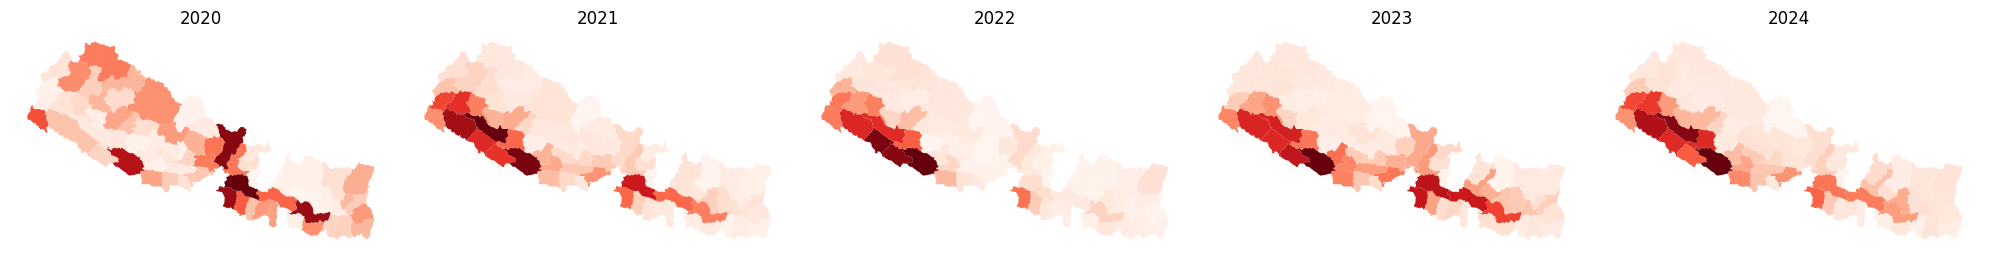

In [50]:
years = [2020, 2021, 2022, 2023, 2024]

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, y in enumerate(years):
    temp = map_df[map_df["year"] == y]
    
    temp.plot(
        column="fire_count",
        cmap="Reds",
        ax=axes[i],
        legend=False,
        missing_kwds={"color": "lightgrey"}
    )
    
    axes[i].set_title(str(y))
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [51]:
district_fire = df.groupby("District")["fire_count"].sum().reset_index()
district_fire = district_fire.sort_values(by="fire_count", ascending=False)

In [53]:
district_fire = df.groupby("District")["fire_count"].mean().reset_index()
district_fire = district_fire.sort_values(by="fire_count", ascending=False)

In [54]:
print(district_fire.head(20))

            District  fire_count
14              DANG      2110.4
71           SURKHET      1827.4
30           KAILALI      1687.2
8            BARDIYA      1520.6
11           CHITWAN      1456.2
6              BANKE      1419.0
40         MAKWANPUR      1279.0
53             PARSA      1219.8
62            SALYAN      1160.0
21              DOTI      1137.4
12        DADELDHURA      1036.6
66          SINDHULI       998.2
76          UDAYAPUR       896.4
32        KANCHANPUR       865.4
0             ACHHAM       830.0
46  NAWALPARASI EAST       709.0
33        KAPILBASTU       708.8
1       ARGHAKHANCHI       631.0
54           PYUTHAN       571.2
26          JAJARKOT       523.8


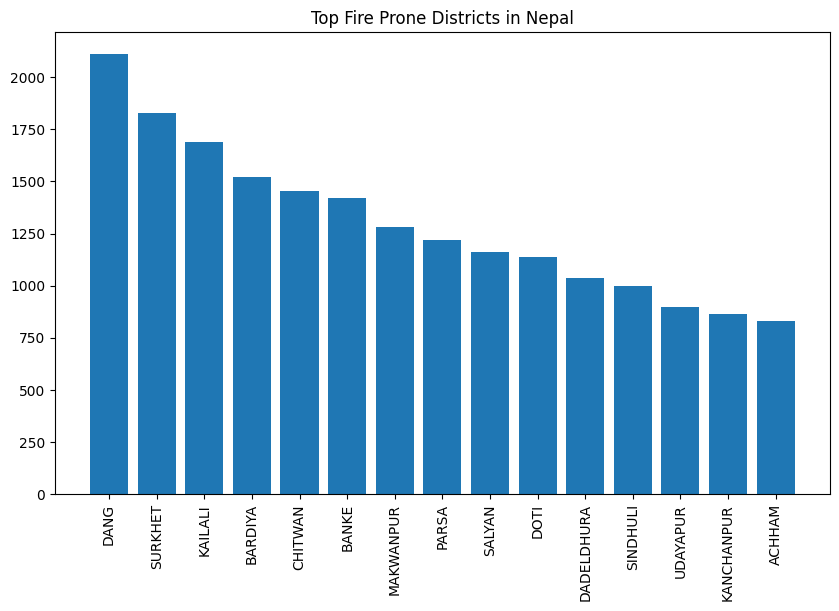

In [55]:
import matplotlib.pyplot as plt

top = district_fire.head(15)

plt.figure(figsize=(10,6))
plt.bar(top["District"], top["fire_count"])
plt.xticks(rotation=90)
plt.title("Top Fire Prone Districts in Nepal")
plt.show()

In [56]:
def classify_fire(x):
    if x > 1000:
        return "Very High"
    elif x > 500:
        return "High"
    elif x > 200:
        return "Medium"
    else:
        return "Low"

district_fire["risk_level"] = district_fire["fire_count"].apply(classify_fire)

In [57]:
map_df = nepal_map.merge(district_fire, left_on="adm2_name", right_on="District")

<Axes: >

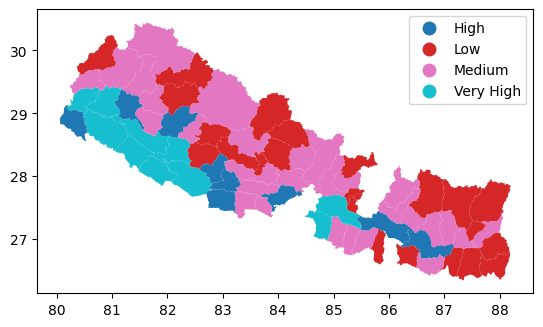

In [58]:
map_df.plot(column="risk_level", legend=True)